<a href="https://colab.research.google.com/github/DogwonLee/Netflix-User-Behavior/blob/main/Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 뜯어보기



In [2]:
import pandas as pd
df = pd.read_csv("/content/netflix_user_behavior_dataset.csv")
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,favorite_genre,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,Sci-Fi,220,17,3,60,1.7,5,66,16,No
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,Documentary,76,15,4,71,4.6,7,78,14,No
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,Comedy,215,6,13,33,2.0,27,29,41,No
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,Action,280,4,9,58,1.2,9,23,22,No
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,Horror,261,15,9,64,1.3,49,56,54,No


In [3]:
print(f"나라:", df['country'].unique())
print(f"결제방식:", df['payment_method'].unique())
print(f"주요기기:", df['primary_device'].unique())
print(f"장르:", df['favorite_genre'].unique())

나라: ['India' 'USA' 'Canada' 'Brazil' 'France' 'Australia' 'UK' 'Japan'
 'Germany' 'Spain']
결제방식: ['PayPal' 'Credit Card' 'UPI' 'Debit Card']
주요기기: ['Laptop' 'Tablet' 'Smart TV' 'Mobile']
장르: ['Sci-Fi' 'Documentary' 'Comedy' 'Action' 'Horror' 'Romance' 'Thriller'
 'Drama']


#데이터 전처리



*   'churned' 수치형으로 변환 ( Yes: 1, No: 0)


*   국가들을 대륙으로 묶어서 대륙 컬럼을 새로 만들까?

*   나이대 컬럼 생성 (10s,20s etc)

*   Outlier 처리
*   결측치 처리







In [ ]:
print(f"최대 평점:",df["rating_given"].max())
print(f"최소 평점:",df["rating_given"].min())

최대 평점: 5.0
최소 평점: 1.0


##Outlier

In [ ]:
# 데이터 기본 통계 확인
print(df[target_cols].describe())

       avg_watch_time_minutes  watch_sessions_per_week  \
count            50000.000000             50000.000000   
mean               154.946520                 9.986920   
std                 83.727292                 5.480616   
min                 10.000000                 1.000000   
25%                 83.000000                 5.000000   
50%                155.000000                10.000000   
75%                228.000000                15.000000   
max                299.000000                19.000000   

       recommendation_click_rate  content_interactions  
count               50000.000000          50000.000000  
mean                   49.563000             24.306380  
std                    28.816997             14.468037  
min                     0.000000              0.000000  
25%                    25.000000             12.000000  
50%                    50.000000             24.000000  
75%                    75.000000             37.000000  
max                  

In [ ]:
import pandas as pd
import numpy as np

# ✅ 분석할 컬럼 직접 지정
target_cols = ["avg_watch_time_minutes", "watch_sessions_per_week", "recommendation_click_rate","content_interactions"]

def detect_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers, lower, upper

for col in target_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"\n📌 {col}")
    print(f"   정상 범위: {lower:.2f} ~ {upper:.2f}")
    print(f"   이상치 수: {len(outliers)}건 ({len(outliers)/len(df)*100:.2f}%)")
    print(outliers[["user_id", col]].head(5).to_string(index=False))


📌 avg_watch_time_minutes
   정상 범위: -134.50 ~ 445.50
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, avg_watch_time_minutes]
Index: []

📌 watch_sessions_per_week
   정상 범위: -10.00 ~ 30.00
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, watch_sessions_per_week]
Index: []

📌 recommendation_click_rate
   정상 범위: -50.00 ~ 150.00
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, recommendation_click_rate]
Index: []

📌 content_interactions
   정상 범위: -25.50 ~ 74.50
   이상치 수: 0건 (0.00%)
Empty DataFrame
Columns: [user_id, content_interactions]
Index: []


##결측치

In [ ]:
# 결측치 확인
print(df.isnull().sum())
print(f"\n전체 결측치 비율: {df.isnull().sum().sum() / df.size * 100:.2f}%")

user_id                      0
age                          0
gender                       0
country                      0
account_age_months           0
subscription_type            0
monthly_fee                  0
payment_method               0
primary_device               0
devices_used                 0
favorite_genre               0
avg_watch_time_minutes       0
watch_sessions_per_week      0
binge_watch_sessions         0
completion_rate              0
rating_given                 0
content_interactions         0
recommendation_click_rate    0
days_since_last_login        0
churned                      0
dtype: int64

전체 결측치 비율: 0.00%


##나이대

In [4]:
import pandas as pd

df = pd.read_csv("netflix_user_behavior_dataset.csv")

# 나이대 컬럼 생성
bins   = [0, 19, 29, 39, 49, 59, 100]
labels = ["10대", "20대", "30대", "40대", "50대", "60대+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=True)

# 확인
print(df[["user_id", "age", "age_group"]].head(10).to_string(index=False))
print("\n나이대 분포:")
print(df["age_group"].value_counts().sort_index())

user_id  age age_group
U100000   56       50대
U100001   46       40대
U100002   32       30대
U100003   60      60대+
U100004   25       20대
U100005   38       30대
U100006   56       50대
U100007   36       30대
U100008   40       40대
U100009   28       20대

나이대 분포:
age_group
10대      2082
20대     10556
30대     10794
40대     10760
50대     10536
60대+     5272
Name: count, dtype: int64


In [6]:
df.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,...,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned,age_group
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,...,220,17,3,60,1.7,5,66,16,No,50대
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,...,76,15,4,71,4.6,7,78,14,No,40대
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,...,215,6,13,33,2.0,27,29,41,No,30대
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,...,280,4,9,58,1.2,9,23,22,No,60대+
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,...,261,15,9,64,1.3,49,56,54,No,20대


In [7]:
df.to_csv("netflix_with_age_group.csv", index=False)



---



#새로운 데이터 로드

In [2]:
import pandas as pd
df2 = pd.read_csv("/content/netflix_with_age_group.csv")
df2.head()

,user_id,age,gender,country,account_age_months,subscription_type,monthly_fee,payment_method,primary_device,devices_used,...,avg_watch_time_minutes,watch_sessions_per_week,binge_watch_sessions,completion_rate,rating_given,content_interactions,recommendation_click_rate,days_since_last_login,churned,age_group
0,U100000,56,Male,India,17,Standard,15.99,PayPal,Laptop,1,...,220,17,3,60,1.7,5,66,16,No,50대
1,U100001,46,Female,USA,20,Standard,12.99,PayPal,Tablet,2,...,76,15,4,71,4.6,7,78,14,No,40대
2,U100002,32,Other,USA,25,Basic,15.99,PayPal,Tablet,2,...,215,6,13,33,2.0,27,29,41,No,30대
3,U100003,60,Male,Canada,37,Standard,12.99,PayPal,Smart TV,3,...,280,4,9,58,1.2,9,23,22,No,60대+
4,U100004,25,Male,Brazil,23,Premium,12.99,PayPal,Mobile,3,...,261,15,9,64,1.3,49,56,54,No,20대


#가설 검정

## 20대 이용자들의 계정 활성화 기간이 가장 길 것이다.






*   종속변수: account_age_months (계정 활성 기간)
*   독립변수: age_group (연령대)



###**분석 방법**



연령대가 계정 활성 기간에 미치는 영향을 분석하기 위해
연령대를 범주형 변수로 처리한 선형회귀모형을 사용하였다.

account_age_months = B0 + B1 * age_group + E

또한 연령대 전체의 효과를 검정하기 위해 분산분석(ANOVA, F-test)을 실시하였다.

In [3]:
#더미변수 포함한 선형회귀

import pandas as pd
import statsmodels.formula.api as smf

# age_group을 범주형으로 변환
df2['age_group'] = df2['age_group'].astype('category')

# 회귀모델
model = smf.ols('account_age_months ~ C(age_group)', data=df2).fit()

# 결과 출력
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     account_age_months   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6732
Date:                Sun, 29 Mar 2026   Prob (F-statistic):              0.644
Time:                        06:37:18   Log-Likelihood:            -2.1276e+05
No. Observations:               50000   AIC:                         4.255e+05
Df Residuals:                   49994   BIC:                         4.256e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               30.3372 

**연령대 전체 효과를 검정하기 위해 ANOVA를 실시하였다.**

In [4]:
# ANOVA
from statsmodels.stats.anova import anova_lm

anova_results = anova_lm(model)
print(anova_results)

                   df        sum_sq     mean_sq         F    PR(>F)
C(age_group)      5.0  9.787000e+02  195.740007  0.673225  0.643736
Residual      49994.0  1.453574e+07  290.749640       NaN       NaN


###**분석 결과**



회귀분석 및 분산분석 결과,
연령대(age_group)의 p-value는 0.63으로 나타났다.

이는 유의수준 0.05 기준에서 통계적으로 유의하지 않은 결과이다.

###**해석**

연령대에 따른 계정 활성 기간의 차이는 통계적으로 유의하지 않았다.

즉, 연령대가 계정 활성 기간에 영향을 미친다고 보기 어렵다.



> “**연령대에 따른 계정 활성 기간의 차이**를 통계적으로 확인하지 못했다.”



###**EDA**

/tmp/ipykernel_37292/2677520464.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df2.groupby('age_group')['account_age_months'].mean()
/tmp/ipykernel_37292/2677520464.py:27: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


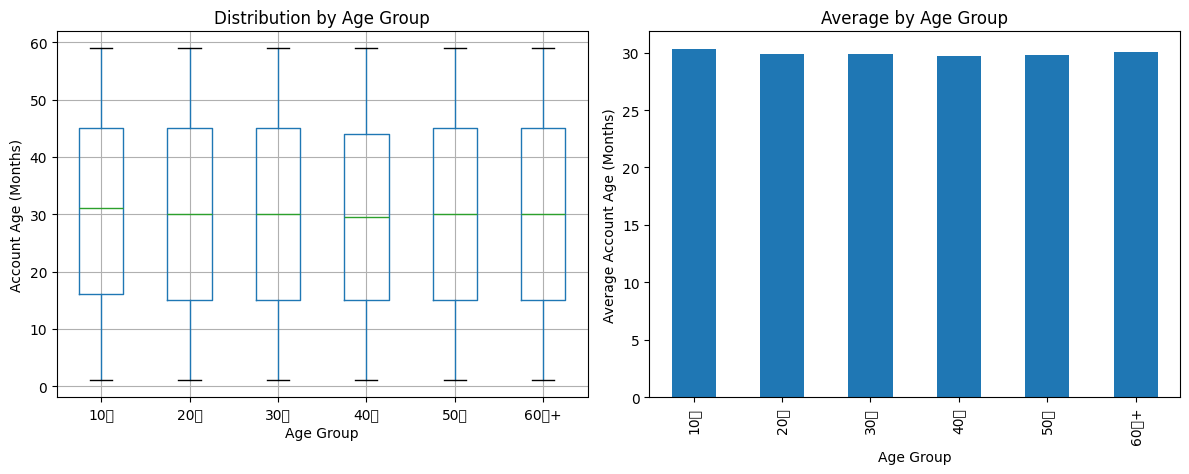

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 평균 계산
mean_values = df2.groupby('age_group')['account_age_months'].mean()

# Figure 생성 (1행 2열)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# 1. 박스플롯
df2.boxplot(column='account_age_months', by='age_group', ax=ax1)
ax1.set_title('Distribution by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Account Age (Months)')

# -------------------
# 2. 평균 바그래프
mean_values.plot(kind='bar', ax=ax2)
ax2.set_title('Average by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Account Age (Months)')

# 전체 제목 제거 (boxplot 기본 타이틀 제거용)
plt.suptitle('')

plt.tight_layout()
plt.show()



1.   **분포 차이 없음**
2.   **평균도 비슷함**





> 이는 연령대보다 **다른 요인**이 계정 활성 기간에 더 큰 영향을 미칠 가능성을 시사한다.





---



##주요기기별 계정 활성 시간은 유의한 차이가 없을 것이다.

###**분석 방법**



*   종속변수 (y): account_age_months → 연속형
*   독립변수 (x): primary_device → 범주형



따라서 **ANOVA** 와 **더미회귀(OLS:최소제곱법**) 를 진행하였다.

In [7]:
import pandas as pd
import statsmodels.formula.api as smf

# 범주형 변환
df2['primary_device'] = df2['primary_device'].astype('category')

# 회귀모델
model2 = smf.ols('account_age_months ~ C(primary_device)', data=df2).fit()

print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:     account_age_months   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                   0.09624
Date:                Sun, 29 Mar 2026   Prob (F-statistic):              0.962
Time:                        06:38:18   Log-Likelihood:            -2.1276e+05
No. Observations:               50000   AIC:                         4.255e+05
Df Residuals:                   49996   BIC:                         4.256e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

In [8]:
from statsmodels.stats.anova import anova_lm

anova_results = anova_lm(model2)
print(anova_results)

                        df        sum_sq     mean_sq         F    PR(>F)
C(primary_device)      3.0  8.394940e+01   27.983133  0.096243  0.962134
Residual           49996.0  1.453663e+07  290.755905       NaN       NaN


###**분석 결과**

**분석 결과 p-value가 0.05보다 크게 나타나, 주요 기기별 계정 활성 기간의 차이는 통계적으로 유의하지 않았다.**

###**해석**



>따라서 기기별로 계정 활성 기간에 차이가 있다고 볼 근거는 확인되지 않았다.



###EDA

/tmp/ipykernel_37292/3733574986.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = df2.groupby('primary_device')['account_age_months'].mean()


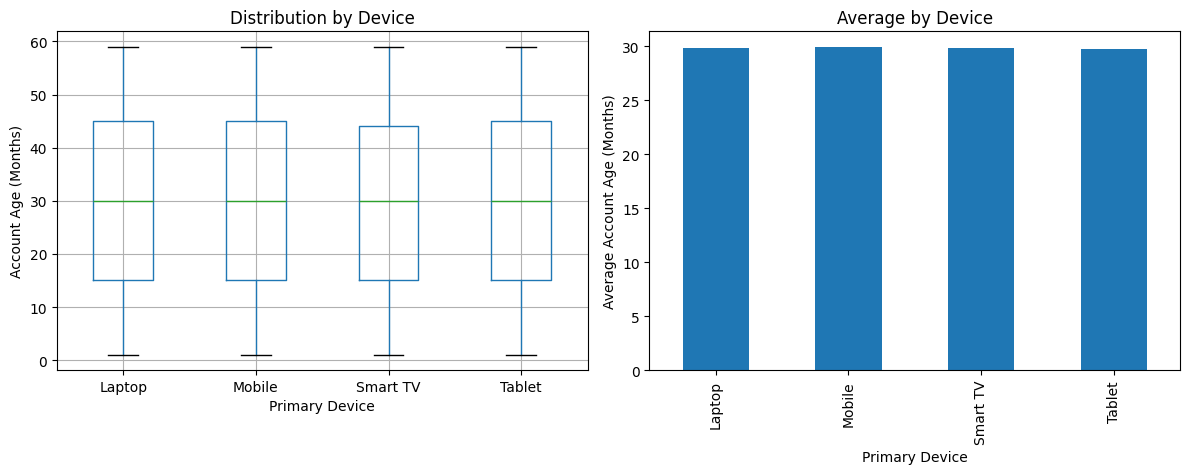

In [9]:
import pandas as pd
import matplotlib.pyplot as plt


# 평균 계산
mean_values = df2.groupby('primary_device')['account_age_months'].mean()

# subplot 생성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# -------------------
# 1. 박스플롯
df2.boxplot(column='account_age_months', by='primary_device', ax=ax1)
ax1.set_title('Distribution by Device')
ax1.set_xlabel('Primary Device')
ax1.set_ylabel('Account Age (Months)')

# -------------------
# 2. 평균 바그래프
mean_values.plot(kind='bar', ax=ax2)
ax2.set_title('Average by Device')
ax2.set_xlabel('Primary Device')
ax2.set_ylabel('Average Account Age (Months)')

# boxplot 기본 타이틀 제거
plt.suptitle('')

plt.tight_layout()
plt.show()